# Dependency Check

In [ ]:
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
}

missing_packages = [
    package_name
    for module_name, package_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    print("Installing missing packages:", ", ".join(missing_packages))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
else:
    print("All required packages are available.")


# Imports and Global Settings

In [ ]:
from pathlib import Path
from urllib.error import HTTPError, URLError
from urllib.request import Request, urlopen
import json
import time
import warnings
import zipfile

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_recall_curve,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42


# Online Dataset Configuration

In [ ]:
PROJECT_DATA_DIR = Path("data") / "cicids2017"
ZIP_PATH = PROJECT_DATA_DIR / "MachineLearningCSV.zip"
EXTRACT_DIR = PROJECT_DATA_DIR / "MachineLearningCSV"
HF_CSV_DIR = PROJECT_DATA_DIR / "huggingface_csvs"

OFFICIAL_DATASET_PAGE = "https://www.unb.ca/cic/datasets/ids-2017.html"
OFFICIAL_CICIDS2017_ZIP_URLS = [
    "http://205.174.165.80/CICDataset/CIC-IDS-2017/Dataset/CIC-IDS-2017/CSVs/MachineLearningCSV.zip",
]

HUGGINGFACE_CSV_URLS = [
    (
        "Monday-WorkingHours.pcap_ISCX.csv",
        "https://huggingface.co/datasets/c01dsnap/CIC-IDS2017/resolve/main/Monday-WorkingHours.pcap_ISCX.csv?download=true",
    ),
    (
        "Tuesday-WorkingHours.pcap_ISCX.csv",
        "https://huggingface.co/datasets/c01dsnap/CIC-IDS2017/resolve/main/Tuesday-WorkingHours.pcap_ISCX.csv?download=true",
    ),
    (
        "Wednesday-workingHours.pcap_ISCX.csv",
        "https://huggingface.co/datasets/c01dsnap/CIC-IDS2017/resolve/main/Wednesday-workingHours.pcap_ISCX.csv?download=true",
    ),
    (
        "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
        "https://huggingface.co/datasets/c01dsnap/CIC-IDS2017/resolve/main/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv?download=true",
    ),
    (
        "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
        "https://huggingface.co/datasets/c01dsnap/CIC-IDS2017/resolve/main/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv?download=true",
    ),
    (
        "Friday-WorkingHours-Morning.pcap_ISCX.csv",
        "https://huggingface.co/datasets/c01dsnap/CIC-IDS2017/resolve/main/Friday-WorkingHours-Morning.pcap_ISCX.csv?download=true",
    ),
    (
        "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
        "https://huggingface.co/datasets/c01dsnap/CIC-IDS2017/resolve/main/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv?download=true",
    ),
    (
        "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
        "https://huggingface.co/datasets/c01dsnap/CIC-IDS2017/resolve/main/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv?download=true",
    ),
]

DOWNLOAD_DATASET = True
FORCE_DOWNLOAD = False
TRY_HUGGINGFACE_FIRST = True
TRY_OFFICIAL_ZIP_FALLBACK = True

CSV_PATTERN = "*.csv"
NROWS_PER_FILE = 100_000       # Set to None to load each full CSV.
MAX_ROWS_AFTER_LOAD = 300_000  # Final sample cap after all CSVs are combined.
CHUNK_SIZE = 100_000

DATA_DIR_CANDIDATES = [
    HF_CSV_DIR,
    EXTRACT_DIR / "MachineLearningCVE",
    EXTRACT_DIR,
    PROJECT_DATA_DIR,
    Path(r"C:\Users\jober\OneDrive\Desktop\BSP\Summer BSP\data"),
    Path(r"C:\Users\jober\OneDrive\Desktop\BSP\Summer BSP"),
]

BENIGN_LABELS = {"BENIGN", "NORMAL", "NORMAL TRAFFIC"}
TARGET_COLUMN_CANDIDATES = ["Label", "label", "Attack", "Class", "class", "target"]


# Online Dataset Download Utilities

In [ ]:
def list_csv_files(folder: Path):
    if not Path(folder).exists():
        return []
    files = sorted(Path(folder).rglob(CSV_PATTERN))
    return [
        path
        for path in files
        if "__MACOSX" not in path.parts and not path.name.startswith(".")
    ]


def find_csv_files(candidates, pattern=CSV_PATTERN):
    for folder in candidates:
        folder = Path(folder)
        if folder.exists():
            files = list_csv_files(folder)
            if files:
                return folder, files
    return None, []


def is_valid_zip(path: Path) -> bool:
    return path.exists() and path.stat().st_size > 0 and zipfile.is_zipfile(path)


def is_valid_csv(path: Path) -> bool:
    if not path.exists() or path.stat().st_size < 1024:
        return False

    with path.open("rb") as file:
        start = file.read(4096).lower()

    if b"<html" in start or b"<!doctype" in start:
        return False

    return b"," in start and (b"label" in start or b"flow" in start)


def download_file(url: str, destination: Path, chunk_size=1024 * 1024):
    destination.parent.mkdir(parents=True, exist_ok=True)
    temporary_path = destination.with_suffix(destination.suffix + ".part")
    request = Request(url, headers={"User-Agent": "Mozilla/5.0"})

    with urlopen(request, timeout=120) as response:
        total = response.headers.get("Content-Length")
        total = int(total) if total is not None else None
        downloaded = 0
        start = time.time()

        with temporary_path.open("wb") as file:
            while True:
                chunk = response.read(chunk_size)
                if not chunk:
                    break
                file.write(chunk)
                downloaded += len(chunk)

                if total:
                    pct = downloaded / total * 100
                    print(f"\rDownloaded {downloaded / 1e6:.1f} MB / {total / 1e6:.1f} MB ({pct:.1f}%)", end="")
                else:
                    print(f"\rDownloaded {downloaded / 1e6:.1f} MB", end="")

    elapsed = max(time.time() - start, 1e-9)
    temporary_path.replace(destination)
    print(f"\nDownload complete: {destination} ({downloaded / 1e6:.1f} MB, {downloaded / 1e6 / elapsed:.1f} MB/s)")
    return destination


def extract_zip(zip_path: Path, extract_dir: Path):
    if not is_valid_zip(zip_path):
        raise zipfile.BadZipFile(f"{zip_path} is not a valid ZIP file.")

    extract_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as archive:
        archive.extractall(extract_dir)
    print(f"Extracted dataset to: {extract_dir}")
    return extract_dir


def download_huggingface_csvs():
    HF_CSV_DIR.mkdir(parents=True, exist_ok=True)
    downloaded_files = []

    for filename, url in HUGGINGFACE_CSV_URLS:
        destination = HF_CSV_DIR / filename

        if destination.exists() and not FORCE_DOWNLOAD:
            if is_valid_csv(destination):
                print(f"Using existing CSV: {destination.name}")
                downloaded_files.append(destination)
                continue

            print(f"Existing CSV looks invalid, replacing it: {destination}")
            destination.unlink()

        print(f"Downloading {filename}")
        download_file(url, destination)

        if not is_valid_csv(destination):
            destination.unlink(missing_ok=True)
            raise RuntimeError(f"Downloaded file is not a valid CSV: {filename}")

        downloaded_files.append(destination)

    return HF_CSV_DIR, downloaded_files


def download_from_official_urls():
    if ZIP_PATH.exists() and not FORCE_DOWNLOAD:
        if is_valid_zip(ZIP_PATH):
            print(f"Using existing valid ZIP: {ZIP_PATH}")
            return ZIP_PATH

        print(f"Existing ZIP is invalid, replacing it: {ZIP_PATH}")
        ZIP_PATH.unlink()

    last_error = None
    for url in OFFICIAL_CICIDS2017_ZIP_URLS:
        try:
            print(f"Downloading CICIDS2017 official ZIP from: {url}")
            download_file(url, ZIP_PATH)

            if not is_valid_zip(ZIP_PATH):
                ZIP_PATH.unlink(missing_ok=True)
                raise zipfile.BadZipFile("Official download did not produce a valid ZIP file.")

            return ZIP_PATH
        except (HTTPError, URLError, TimeoutError, OSError, zipfile.BadZipFile) as error:
            last_error = error
            print(f"Download failed for {url}: {error}")

    raise RuntimeError(f"All official URL downloads failed. Last error: {last_error}")


def add_data_candidate(path):
    path = Path(path)
    if path not in DATA_DIR_CANDIDATES:
        DATA_DIR_CANDIDATES.insert(0, path)


def ensure_online_dataset():
    existing_folder, existing_files = find_csv_files(DATA_DIR_CANDIDATES)
    if existing_files and not FORCE_DOWNLOAD:
        print(f"Using existing CSV files under: {existing_folder}")
        return existing_folder, existing_files

    if not DOWNLOAD_DATASET:
        print("DOWNLOAD_DATASET is False. Skipping online download.")
        return existing_folder, existing_files

    if TRY_HUGGINGFACE_FIRST:
        try:
            folder, files = download_huggingface_csvs()
            if files:
                add_data_candidate(folder)
                return folder, files
        except Exception as error:
            print(f"Hugging Face CSV download failed: {error}")

    if TRY_OFFICIAL_ZIP_FALLBACK:
        try:
            zip_path = download_from_official_urls()
            extract_zip(zip_path, EXTRACT_DIR)
            folder, files = find_csv_files([EXTRACT_DIR, PROJECT_DATA_DIR])
            if files:
                add_data_candidate(folder)
                return folder, files
        except Exception as error:
            print(f"Official ZIP download path failed: {error}")

    return None, []


# CSV Loading Utilities


In [ ]:
def clean_column_names(df: pd.DataFrame) -> pd.DataFrame:
    cleaned = df.copy()
    cleaned.columns = [
        str(col)
        .strip()
        .replace(" ", "_")
        .replace("/", "_per_")
        .replace("-", "_")
        for col in cleaned.columns
    ]
    return cleaned


def read_csv_with_fallback(path: Path, nrows=None) -> pd.DataFrame:
    for encoding in ("utf-8", "latin1", "cp1252"):
        try:
            return pd.read_csv(path, nrows=nrows, low_memory=False, encoding=encoding)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path, nrows=nrows, low_memory=False)


def read_csv_sample_with_fallback(path: Path, max_rows=None, chunksize=CHUNK_SIZE) -> pd.DataFrame:
    if max_rows is None:
        return clean_column_names(read_csv_with_fallback(path, nrows=None))

    last_error = None
    for encoding in ("utf-8", "latin1", "cp1252"):
        try:
            sample = pd.DataFrame()
            rows_seen = 0
            seed_offset = sum(ord(char) for char in path.name)

            reader = pd.read_csv(
                path,
                chunksize=chunksize,
                low_memory=False,
                encoding=encoding,
            )

            for chunk in reader:
                chunk = clean_column_names(chunk)
                rows_seen += len(chunk)
                sample = pd.concat([sample, chunk], ignore_index=True, sort=False)

                if len(sample) > max_rows:
                    sample = sample.sample(
                        max_rows,
                        random_state=RANDOM_STATE + seed_offset + rows_seen,
                    ).reset_index(drop=True)

            return sample
        except UnicodeDecodeError as error:
            last_error = error
            continue

    raise RuntimeError(f"Could not read {path}. Last error: {last_error}")


def load_csv_folder(files, nrows_per_file=None, max_rows_after_load=None) -> pd.DataFrame:
    frames = []

    for path in files:
        print(f"Loading {path.name}")
        frame = read_csv_sample_with_fallback(path, max_rows=nrows_per_file)
        frame["source_file"] = path.name
        frames.append(frame)

    data = pd.concat(frames, ignore_index=True, sort=False)

    if max_rows_after_load is not None and len(data) > max_rows_after_load:
        data = data.sample(max_rows_after_load, random_state=RANDOM_STATE).reset_index(drop=True)

    return data



def normalize_cicids_label(value):
    label = str(value).strip()
    label = label.replace("\\ufffd", "-")
    label = label.replace("\ufffd", "-")
    label = label.replace("–", "-")
    label = label.replace("—", "-")
    label = " ".join(label.split())
    label = label.replace(" - ", "-").replace("-", " - ")
    label = " ".join(label.split())

    replacements = {
        "Web Attack - Brute Force": "Web Attack - Brute Force",
        "Web Attack - Sql Injection": "Web Attack - SQL Injection",
        "Web Attack - XSS": "Web Attack - XSS",
        "Infilteration": "Infiltration",
    }
    return replacements.get(label, label)


def find_target_column(df: pd.DataFrame) -> str:
    for candidate in TARGET_COLUMN_CANDIDATES:
        normalized = candidate.strip().replace(" ", "_")
        if normalized in df.columns:
            return normalized

    label_like = [col for col in df.columns if "label" in col.lower() or "attack" in col.lower()]
    if label_like:
        return label_like[0]

    raise ValueError("No target column found. Update TARGET_COLUMN_CANDIDATES with the label column name.")


# Download and Load Dataset


In [ ]:
data_folder, csv_files = ensure_online_dataset()

if not csv_files:
    data_folder, csv_files = find_csv_files(DATA_DIR_CANDIDATES)

if not csv_files:
    raise FileNotFoundError(
        "Could not download or locate CICIDS2017 CSV files. "
        "Check your internet connection, remove any corrupt files under data/cicids2017, "
        "or manually place the CICIDS2017 CSV files in data/cicids2017."
    )

print(f"Found {len(csv_files)} CSV file(s) under: {data_folder}")
raw_data = load_csv_folder(
    csv_files,
    nrows_per_file=NROWS_PER_FILE,
    max_rows_after_load=MAX_ROWS_AFTER_LOAD,
)
dataset_source = str(data_folder)

raw_data = clean_column_names(raw_data)
target_column = find_target_column(raw_data)
raw_data[target_column] = raw_data[target_column].apply(normalize_cicids_label)

print(f"Dataset source: {dataset_source}")
print(f"Dataset shape: {raw_data.shape}")
print(f"Target column: {target_column}")
raw_data.head()


Using existing CSV files under: data/cicids2017/huggingface_csvs
Found 8 CSV file(s) under: data/cicids2017/huggingface_csvs
Loading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loading Friday-WorkingHours-Morning.pcap_ISCX.csv
Loading Monday-WorkingHours.pcap_ISCX.csv
Loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loading Tuesday-WorkingHours.pcap_ISCX.csv
Loading Wednesday-workingHours.pcap_ISCX.csv
Dataset source: data/cicids2017/huggingface_csvs
Dataset shape: (300000, 80)
Target column: Label


,Destination_Port,Flow_Duration,Total_Fwd_Packets,Total_Backward_Packets,Total_Length_of_Fwd_Packets,Total_Length_of_Bwd_Packets,Fwd_Packet_Length_Max,Fwd_Packet_Length_Min,Fwd_Packet_Length_Mean,Fwd_Packet_Length_Std,Bwd_Packet_Length_Max,Bwd_Packet_Length_Min,Bwd_Packet_Length_Mean,Bwd_Packet_Length_Std,Flow_Bytes_per_s,Flow_Packets_per_s,Flow_IAT_Mean,Flow_IAT_Std,Flow_IAT_Max,Flow_IAT_Min,Fwd_IAT_Total,Fwd_IAT_Mean,Fwd_IAT_Std,Fwd_IAT_Max,Fwd_IAT_Min,Bwd_IAT_Total,Bwd_IAT_Mean,Bwd_IAT_Std,Bwd_IAT_Max,Bwd_IAT_Min,Fwd_PSH_Flags,Bwd_PSH_Flags,Fwd_URG_Flags,Bwd_URG_Flags,Fwd_Header_Length,Bwd_Header_Length,Fwd_Packets_per_s,Bwd_Packets_per_s,Min_Packet_Length,Max_Packet_Length,Packet_Length_Mean,Packet_Length_Std,Packet_Length_Variance,FIN_Flag_Count,SYN_Flag_Count,RST_Flag_Count,PSH_Flag_Count,ACK_Flag_Count,URG_Flag_Count,CWE_Flag_Count,ECE_Flag_Count,Down_per_Up_Ratio,Average_Packet_Size,Avg_Fwd_Segment_Size,Avg_Bwd_Segment_Size,Fwd_Header_Length.1,Fwd_Avg_Bytes_per_Bulk,Fwd_Avg_Packets_per_Bulk,Fwd_Avg_Bulk_Rate,Bwd_Avg_Bytes_per_Bulk,Bwd_Avg_Packets_per_Bulk,Bwd_Avg_Bulk_Rate,Subflow_Fwd_Packets,Subflow_Fwd_Bytes,Subflow_Bwd_Packets,Subflow_Bwd_Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,Label,source_file
0,53,62293,2,2,72,296,36,36,36.000000,0.000000,148,148,148.000000,0.000000,5907.565858,64.212672,20764.33333,3.595882e+04,62286,3,3,3.000,0.000,3,3,4,4.000000e+00,0.000000e+00,4,4,0,0,0,0,64,64,32.106336,32.106336,36,148,80.800000,61.344926,3763.20000,0,0,0,0,0,0,0,0,1,101.000000,36.000000,148.000000,64,0,0,0,0,0,0,2,72,2,296,-1,-1,1,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Morning.pcap_ISCX.csv
1,443,4498638,9,5,376,5422,189,0,41.777778,68.034509,2260,0,1084.400000,942.038640,1288.834532,3.112053,346049.07690,9.600103e+05,3475718,4,4498638,562329.750,1200694.719,3475718,4,920005,2.300012e+05,3.614952e+05,760437,50,0,0,0,0,192,112,2.000606,1.111448,0,2260,386.533333,719.175209,517212.98100,0,0,0,1,0,0,0,0,0,414.142857,41.777778,1084.400000,192,0,0,0,0,0,0,9,376,5,5422,8192,11,8,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Morning.pcap_ISCX.csv
2,443,10268877,7,5,642,1254,325,0,91.714286,130.801012,1077,0,250.800000,467.098170,184.635574,1.168580,933534.27270,2.941434e+06,9800607,64,10300000,1710198.667,3964593.760,9800607,82,10200000,2.549446e+06,4.967535e+06,10000000,7789,0,0,0,0,152,108,0.681671,0.486908,0,1077,145.846154,298.919679,89352.97436,0,0,0,1,0,0,0,0,0,158.000000,91.714286,250.800000,152,0,0,0,0,0,0,7,642,5,1254,8192,4764,6,20,460585.0,0.0,460585,460585,9800607.0,0.0,9800607,9800607,BENIGN,Thursday-WorkingHours-Afternoon-Infilteration....
3,443,5850588,9,7,386,5463,205,0,42.888889,72.844774,2021,0,780.428571,838.383734,999.728574,2.734768,390039.20000,1.416442e+06,5505497,4,5850588,731323.500,1931209.973,5505503,4,314023,5.233717e+04,9.267693e+04,238163,219,0,0,0,0,204,152,1.538307,1.196461,0,2021,344.058824,638.719957,407963.18380,0,0,0,1,0,0,0,0,0,365.562500,42.888889,780.428571,204,0,0,0,0,0,0,9,386,7,5463,8192,119,7,20,345087.0,0.0,345087,345087,5505497.0,0.0,5505497,5505497,BENIGN,Thursday-WorkingHours-Morning-WebAttacks.pcap_...
4,1029,71,1,1,0,6,0,0,0.000000,0.000000,6,6,6.000000,0.000000,84507.042250,28169.014080,71.00000,0.000000e+00,71,71,0,0.000,0.000,0,0,0,0.000000e+00,0.000000e+00,0,0,0,0,0,0,40,20,14084.507040,14084.507040,0,6,2.000000,3.464102,12.00000,0,0,0,1,0,0,0,0,1,3.000000,0.000000,6.000000,40,0,0,0,0,0,0,1,0,1,6,29200,0,0,40,0.0,0.0,0,0,0.0,0.0,0,0,PortScan,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...


# Project Scope and Dataset Context

In [ ]:
project_scope = {
    "dataset": "CICIDS2017",
    "problem": "Network intrusion detection from labelled network-flow features",
    "binary_task": "Detect whether a flow is BENIGN or ATTACK",
    "multiclass_task": "Classify the attack category when multiple labels are available",
    "main_research_question": (
        "Can machine learning models effectively detect and classify network intrusion attempts "
        "from traffic-flow data, and how do they compare with rule-based baselines?"
    ),
    "practical_priority": (
        "For an IDS, false negatives are dangerous because attacks are missed; "
        "false positives are also costly because analysts may waste time."
    ),
}

for key, value in project_scope.items():
    print(f"{key}: {value}")

if "source_file" in raw_data.columns:
    source_file_counts = raw_data["source_file"].value_counts().to_frame("rows")
    display(source_file_counts)


dataset: CICIDS2017
problem: Network intrusion detection from labelled network-flow features
binary_task: Detect whether a flow is BENIGN or ATTACK
multiclass_task: Classify the attack category when multiple labels are available
main_research_question: Can machine learning models effectively detect and classify network intrusion attempts from traffic-flow data, and how do they compare with rule-based baselines?
practical_priority: For an IDS, false negatives are dangerous because attacks are missed; false positives are also costly because analysts may waste time.


,rows
source_file,
Tuesday-WorkingHours.pcap_ISCX.csv,37624
Friday-WorkingHours-Morning.pcap_ISCX.csv,37600
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv,37576
Monday-WorkingHours.pcap_ISCX.csv,37570
Wednesday-workingHours.pcap_ISCX.csv,37442
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv,37412
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,37412
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv,37364


# Dataset Overview

In [ ]:
display(raw_data.info())
display(raw_data.describe(include="all").T.head(25))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 80 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Destination_Port             300000 non-null  int64  
 1   Flow_Duration                300000 non-null  int64  
 2   Total_Fwd_Packets            300000 non-null  int64  
 3   Total_Backward_Packets       300000 non-null  int64  
 4   Total_Length_of_Fwd_Packets  300000 non-null  int64  
 5   Total_Length_of_Bwd_Packets  300000 non-null  int64  
 6   Fwd_Packet_Length_Max        300000 non-null  int64  
 7   Fwd_Packet_Length_Min        300000 non-null  int64  
 8   Fwd_Packet_Length_Mean       300000 non-null  float64
 9   Fwd_Packet_Length_Std        300000 non-null  float64
 10  Bwd_Packet_Length_Max        300000 non-null  int64  
 11  Bwd_Packet_Length_Min        300000 non-null  int64  
 12  Bwd_Packet_Length_Mean       300000 non-null  float64
 13 

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Destination_Port,300000.0,NaN,NaN,NaN,8936.894597,18945.348905,0.0,53.0,80.0,1074.0,65535.0
Flow_Duration,300000.0,NaN,NaN,NaN,9309324.726967,27249640.581014,-12.0,133.0,24013.0,273808.5,119999965.0
Total_Fwd_Packets,300000.0,NaN,NaN,NaN,7.60781,634.149608,1.0,1.0,2.0,3.0,217797.0
Total_Backward_Packets,300000.0,NaN,NaN,NaN,8.300407,825.267105,0.0,1.0,2.0,2.0,289585.0
Total_Length_of_Fwd_Packets,300000.0,NaN,NaN,NaN,474.226997,4980.790544,0.0,6.0,58.0,94.0,1288022.0
Total_Length_of_Bwd_Packets,300000.0,NaN,NaN,NaN,12561.612423,2021227.848287,0.0,6.0,115.0,286.0,639650620.0
Fwd_Packet_Length_Max,300000.0,NaN,NaN,NaN,176.42326,745.566336,0.0,6.0,33.0,48.0,23360.0
Fwd_Packet_Length_Min,300000.0,NaN,NaN,NaN,21.603497,66.635281,0.0,0.0,6.0,38.0,1472.0
Fwd_Packet_Length_Mean,300000.0,NaN,NaN,NaN,55.262946,196.23873,0.0,6.0,32.0,45.0,5177.25641
Fwd_Packet_Length_Std,300000.0,NaN,NaN,NaN,56.603957,297.342098,0.0,0.0,0.0,3.464102,6692.644993


# Class Distribution

,count
Label,
BENIGN,254521
PortScan,20893
DDoS,19074
DoS Hulk,2307
DoS GoldenEye,1424
SSH - Patator,574
Bot,377
Web Attack - Brute Force,352
FTP - Patator,248


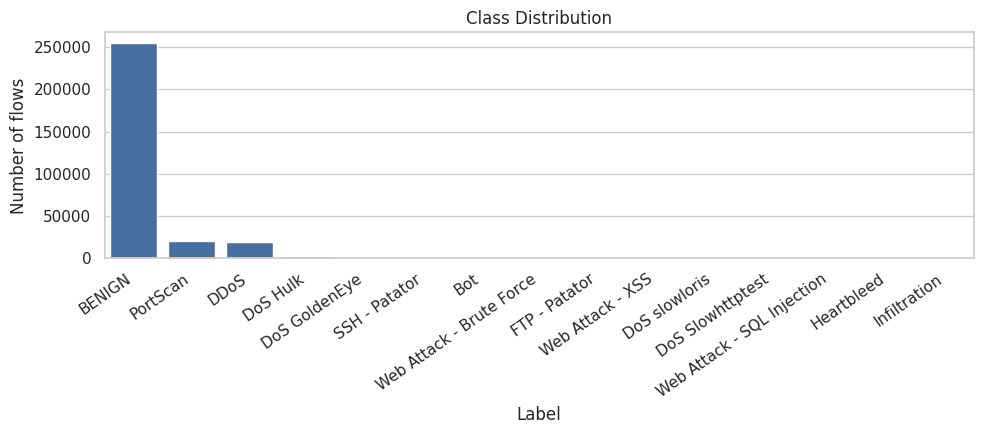

In [ ]:
label_counts = raw_data[target_column].astype(str).str.strip().value_counts()
display(label_counts.to_frame("count"))

plt.figure(figsize=(10, 4.5))
sns.barplot(x=label_counts.index.astype(str), y=label_counts.values, color="#386cb0")
plt.xticks(rotation=35, ha="right")
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Number of flows")
plt.tight_layout()
plt.show()


# Attack-Type Analysis

,count,percentage_of_attacks
Label,,
PortScan,20893,45.939884
DDoS,19074,41.940236
DoS Hulk,2307,5.072671
DoS GoldenEye,1424,3.131115
SSH - Patator,574,1.262121
Bot,377,0.828954
Web Attack - Brute Force,352,0.773984
FTP - Patator,248,0.545307
Web Attack - XSS,149,0.327624


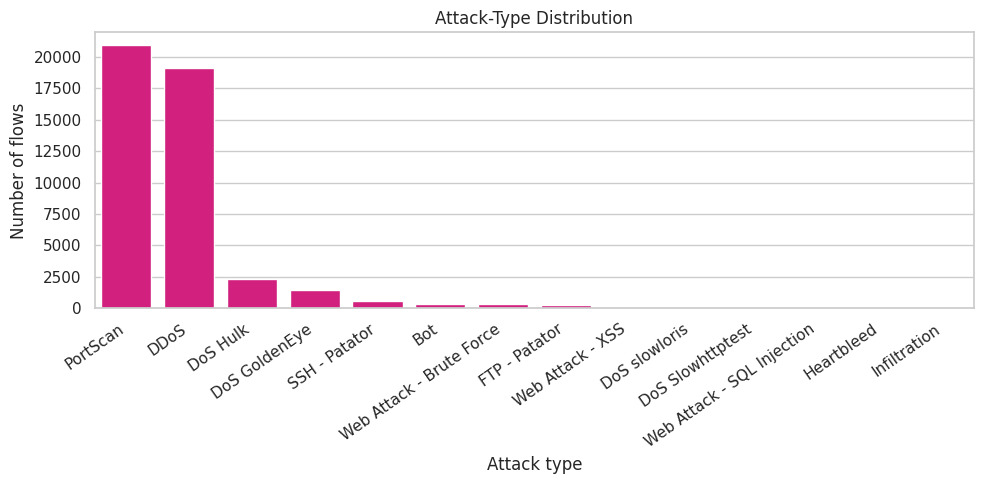

,count
Label,
BENIGN,254521
DoS/DDoS,22880
Reconnaissance,20893
Other Attack,822
Web/Brute Force,505
Botnet,377
Infiltration,2


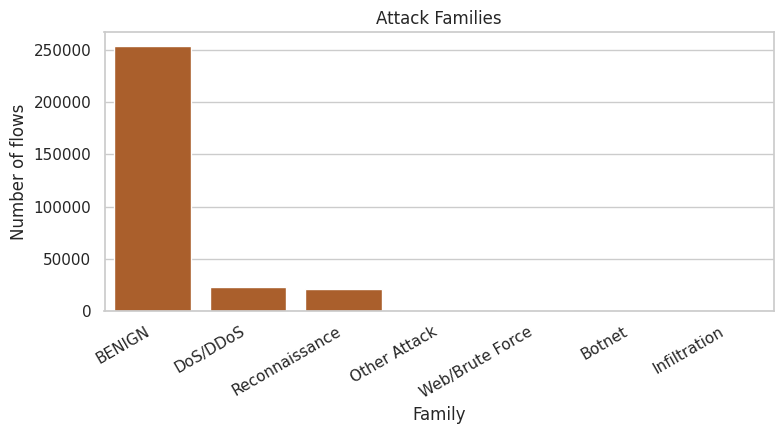

Label,BENIGN,Bot,DDoS,DoS GoldenEye,DoS Hulk,DoS Slowhttptest,DoS slowloris,FTP - Patator,Heartbleed,Infiltration,PortScan,SSH - Patator,Web Attack - Brute Force,Web Attack - SQL Injection,Web Attack - XSS
source_file,,,,,,,,,,,,,,,
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,18338,0,19074,0,0,0,0,0,0,0,0,0,0,0,0
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv,16471,0,0,0,0,0,0,0,0,0,20893,0,0,0,0
Friday-WorkingHours-Morning.pcap_ISCX.csv,37223,377,0,0,0,0,0,0,0,0,0,0,0,0,0
Monday-WorkingHours.pcap_ISCX.csv,37570,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv,37410,0,0,0,0,0,0,0,0,2,0,0,0,0,0
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv,37071,0,0,0,0,0,0,0,0,0,0,0,352,4,149
Tuesday-WorkingHours.pcap_ISCX.csv,36802,0,0,0,0,0,0,248,0,0,0,574,0,0,0
Wednesday-workingHours.pcap_ISCX.csv,33636,0,0,1424,2307,29,43,0,3,0,0,0,0,0,0


In [ ]:
raw_labels = raw_data[target_column].astype(str).str.strip()
raw_labels_upper = raw_labels.str.upper()
binary_from_raw = np.where(raw_labels_upper.isin(BENIGN_LABELS), "BENIGN", "ATTACK")

attack_labels = raw_labels[~raw_labels_upper.isin(BENIGN_LABELS)]
attack_type_summary = attack_labels.value_counts().to_frame("count")

if not attack_type_summary.empty:
    attack_type_summary["percentage_of_attacks"] = (
        attack_type_summary["count"] / attack_type_summary["count"].sum() * 100
    )
    display(attack_type_summary)

    plt.figure(figsize=(10, 5))
    sns.barplot(
        x=attack_type_summary.index.astype(str),
        y=attack_type_summary["count"],
        color="#f0027f",
    )
    plt.xticks(rotation=35, ha="right")
    plt.title("Attack-Type Distribution")
    plt.xlabel("Attack type")
    plt.ylabel("Number of flows")
    plt.tight_layout()
    plt.show()
else:
    print("No attack labels found in the loaded sample.")


def attack_family(label):
    value = str(label).upper()
    if value in BENIGN_LABELS:
        return "BENIGN"
    if "DDOS" in value or "DOS" in value or "HEARTBLEED" in value:
        return "DoS/DDoS"
    if "PORTSCAN" in value or "SCAN" in value:
        return "Reconnaissance"
    if "WEB" in value or "XSS" in value or "SQL" in value or "BRUTE" in value:
        return "Web/Brute Force"
    if "BOT" in value:
        return "Botnet"
    if "INFILTRATION" in value:
        return "Infiltration"
    return "Other Attack"


attack_family_counts = raw_labels.map(attack_family).value_counts().to_frame("count")
display(attack_family_counts)

plt.figure(figsize=(8, 4.5))
sns.barplot(
    x=attack_family_counts.index.astype(str),
    y=attack_family_counts["count"],
    color="#bf5b17",
)
plt.xticks(rotation=30, ha="right")
plt.title("Attack Families")
plt.xlabel("Family")
plt.ylabel("Number of flows")
plt.tight_layout()
plt.show()

if "source_file" in raw_data.columns:
    source_attack_table = pd.crosstab(raw_data["source_file"], raw_labels)
    display(source_attack_table)


# Class Imbalance Analysis

,count,percentage
binary_label,,
BENIGN,254521,84.840333
ATTACK,45479,15.159667


Binary imbalance ratio: 5.60:1


,count,percentage
Label,,
BENIGN,254521,84.840333
PortScan,20893,6.964333
DDoS,19074,6.358000
DoS Hulk,2307,0.769000
DoS GoldenEye,1424,0.474667
SSH - Patator,574,0.191333
Bot,377,0.125667
Web Attack - Brute Force,352,0.117333
FTP - Patator,248,0.082667


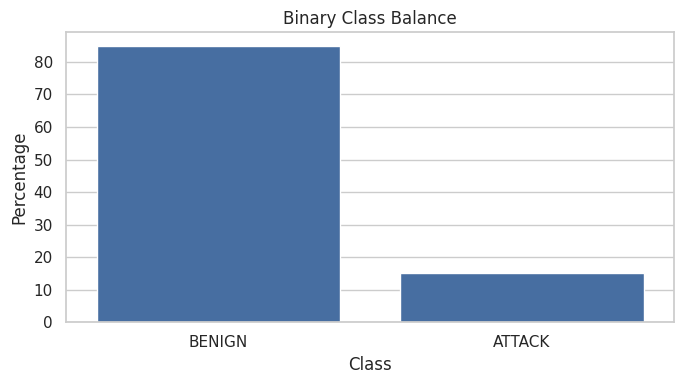

In [ ]:
binary_balance = pd.Series(binary_from_raw, name="binary_label").value_counts().to_frame("count")
binary_balance["percentage"] = binary_balance["count"] / binary_balance["count"].sum() * 100
display(binary_balance)

if len(binary_balance) == 2:
    majority_count = binary_balance["count"].max()
    minority_count = binary_balance["count"].min()
    imbalance_ratio = majority_count / minority_count
    print(f"Binary imbalance ratio: {imbalance_ratio:.2f}:1")
else:
    imbalance_ratio = np.nan
    print("Only one binary class is present in the current sample.")

multiclass_balance = raw_labels.value_counts().to_frame("count")
multiclass_balance["percentage"] = multiclass_balance["count"] / multiclass_balance["count"].sum() * 100
display(multiclass_balance)

plt.figure(figsize=(7, 4))
sns.barplot(x=binary_balance.index, y=binary_balance["percentage"], color="#386cb0")
plt.title("Binary Class Balance")
plt.xlabel("Class")
plt.ylabel("Percentage")
plt.tight_layout()
plt.show()


# Missing Values

,missing_ratio
Flow_Bytes_per_s,0.000157
Destination_Port,0.000000
Total_Fwd_Packets,0.000000
Flow_Duration,0.000000
Total_Length_of_Fwd_Packets,0.000000
Total_Length_of_Bwd_Packets,0.000000
Fwd_Packet_Length_Max,0.000000
Total_Backward_Packets,0.000000
Fwd_Packet_Length_Min,0.000000
Fwd_Packet_Length_Mean,0.000000


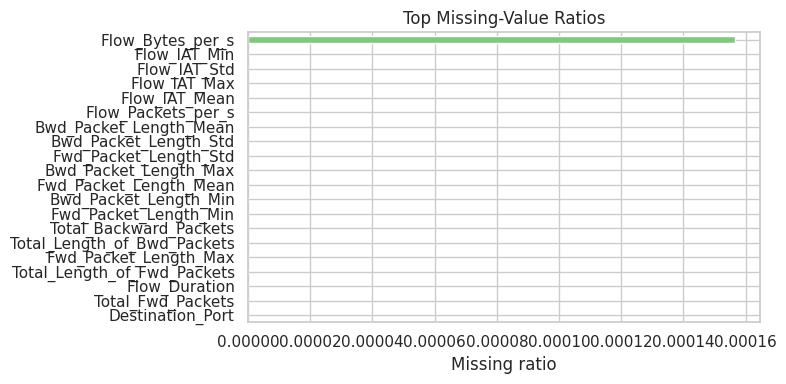

In [ ]:
missing_ratio = raw_data.isna().mean().sort_values(ascending=False)
display(missing_ratio.head(20).to_frame("missing_ratio"))

plt.figure(figsize=(8, 4))
missing_ratio.head(20).sort_values().plot(kind="barh", color="#7fc97f")
plt.title("Top Missing-Value Ratios")
plt.xlabel("Missing ratio")
plt.tight_layout()
plt.show()


# Preprocessing Helpers

In [ ]:
def make_binary_target(y_raw: pd.Series) -> pd.Series:
    labels = y_raw.astype(str).str.strip()
    labels_upper = labels.str.upper()
    return pd.Series(
        np.where(labels_upper.isin(BENIGN_LABELS), "BENIGN", "ATTACK"),
        index=y_raw.index,
        name="binary_label",
    )


def build_feature_matrix(df: pd.DataFrame, target_col: str):
    y_raw = df[target_col].astype(str).str.strip()
    y_binary = make_binary_target(y_raw)

    drop_candidates = {
        target_col,
        "source_file",
        "Flow_ID",
        "Timestamp",
        "Source_IP",
        "Destination_IP",
        "Src_IP",
        "Dst_IP",
        "Source_Port",
        "Destination_Port",
    }

    X = df.drop(columns=[col for col in drop_candidates if col in df.columns], errors="ignore")
    X = X.select_dtypes(include=[np.number]).copy()
    X = X.replace([np.inf, -np.inf], np.nan)

    if X.empty:
        raise ValueError("No numeric feature columns were found after preprocessing.")

    missing = X.isna().mean()
    X = X.loc[:, missing < 0.40]
    medians = X.median(numeric_only=True)
    X = X.fillna(medians)

    constant_cols = [col for col in X.columns if X[col].nunique(dropna=False) <= 1]
    X = X.drop(columns=constant_cols, errors="ignore")

    return X, y_binary, y_raw


X, y_binary, y_raw = build_feature_matrix(raw_data, target_column)

print(f"Feature matrix shape: {X.shape}")
print(f"Binary labels: {y_binary.value_counts().to_dict()}")
display(X.head())


Feature matrix shape: (300000, 69)
Binary labels: {'BENIGN': 254521, 'ATTACK': 45479}


,Flow_Duration,Total_Fwd_Packets,Total_Backward_Packets,Total_Length_of_Fwd_Packets,Total_Length_of_Bwd_Packets,Fwd_Packet_Length_Max,Fwd_Packet_Length_Min,Fwd_Packet_Length_Mean,Fwd_Packet_Length_Std,Bwd_Packet_Length_Max,Bwd_Packet_Length_Min,Bwd_Packet_Length_Mean,Bwd_Packet_Length_Std,Flow_Bytes_per_s,Flow_Packets_per_s,Flow_IAT_Mean,Flow_IAT_Std,Flow_IAT_Max,Flow_IAT_Min,Fwd_IAT_Total,Fwd_IAT_Mean,Fwd_IAT_Std,Fwd_IAT_Max,Fwd_IAT_Min,Bwd_IAT_Total,Bwd_IAT_Mean,Bwd_IAT_Std,Bwd_IAT_Max,Bwd_IAT_Min,Fwd_PSH_Flags,Fwd_URG_Flags,Fwd_Header_Length,Bwd_Header_Length,Fwd_Packets_per_s,Bwd_Packets_per_s,Min_Packet_Length,Max_Packet_Length,Packet_Length_Mean,Packet_Length_Std,Packet_Length_Variance,FIN_Flag_Count,SYN_Flag_Count,RST_Flag_Count,PSH_Flag_Count,ACK_Flag_Count,URG_Flag_Count,CWE_Flag_Count,ECE_Flag_Count,Down_per_Up_Ratio,Average_Packet_Size,Avg_Fwd_Segment_Size,Avg_Bwd_Segment_Size,Fwd_Header_Length.1,Subflow_Fwd_Packets,Subflow_Fwd_Bytes,Subflow_Bwd_Packets,Subflow_Bwd_Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min
0,62293,2,2,72,296,36,36,36.000000,0.000000,148,148,148.000000,0.000000,5907.565858,64.212672,20764.33333,3.595882e+04,62286,3,3,3.000,0.000,3,3,4,4.000000e+00,0.000000e+00,4,4,0,0,64,64,32.106336,32.106336,36,148,80.800000,61.344926,3763.20000,0,0,0,0,0,0,0,0,1,101.000000,36.000000,148.000000,64,2,72,2,296,-1,-1,1,32,0.0,0.0,0,0,0.0,0.0,0,0
1,4498638,9,5,376,5422,189,0,41.777778,68.034509,2260,0,1084.400000,942.038640,1288.834532,3.112053,346049.07690,9.600103e+05,3475718,4,4498638,562329.750,1200694.719,3475718,4,920005,2.300012e+05,3.614952e+05,760437,50,0,0,192,112,2.000606,1.111448,0,2260,386.533333,719.175209,517212.98100,0,0,0,1,0,0,0,0,0,414.142857,41.777778,1084.400000,192,9,376,5,5422,8192,11,8,20,0.0,0.0,0,0,0.0,0.0,0,0
2,10268877,7,5,642,1254,325,0,91.714286,130.801012,1077,0,250.800000,467.098170,184.635574,1.168580,933534.27270,2.941434e+06,9800607,64,10300000,1710198.667,3964593.760,9800607,82,10200000,2.549446e+06,4.967535e+06,10000000,7789,0,0,152,108,0.681671,0.486908,0,1077,145.846154,298.919679,89352.97436,0,0,0,1,0,0,0,0,0,158.000000,91.714286,250.800000,152,7,642,5,1254,8192,4764,6,20,460585.0,0.0,460585,460585,9800607.0,0.0,9800607,9800607
3,5850588,9,7,386,5463,205,0,42.888889,72.844774,2021,0,780.428571,838.383734,999.728574,2.734768,390039.20000,1.416442e+06,5505497,4,5850588,731323.500,1931209.973,5505503,4,314023,5.233717e+04,9.267693e+04,238163,219,0,0,204,152,1.538307,1.196461,0,2021,344.058824,638.719957,407963.18380,0,0,0,1,0,0,0,0,0,365.562500,42.888889,780.428571,204,9,386,7,5463,8192,119,7,20,345087.0,0.0,345087,345087,5505497.0,0.0,5505497,5505497
4,71,1,1,0,6,0,0,0.000000,0.000000,6,6,6.000000,0.000000,84507.042250,28169.014080,71.00000,0.000000e+00,71,71,0,0.000,0.000,0,0,0,0.000000e+00,0.000000e+00,0,0,0,0,40,20,14084.507040,14084.507040,0,6,2.000000,3.464102,12.00000,0,0,0,1,0,0,0,0,1,3.000000,0.000000,6.000000,40,1,0,1,6,29200,0,0,40,0.0,0.0,0,0,0.0,0.0,0,0


# Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_binary,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_binary,
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")


Train shape: (225000, 69)
Test shape: (75000, 69)


# Rule-Based Baseline Helpers

In [ ]:
RISKY_FEATURE_KEYWORDS = [
    "flow_bytes",
    "flow_packets",
    "packet_length",
    "fwd_packet",
    "bwd_packet",
    "syn_flag",
    "rst_flag",
    "psh_flag",
    "init_win",
]


def rule_based_predict(X_reference, y_reference, X_eval, quantile=0.995):
    candidate_cols = [
        col for col in X_reference.columns
        if any(keyword in col.lower() for keyword in RISKY_FEATURE_KEYWORDS)
    ]

    if not candidate_cols:
        majority = y_reference.value_counts().idxmax()
        return pd.Series(np.repeat(majority, len(X_eval)), index=X_eval.index)

    benign_reference = X_reference.loc[y_reference.eq("BENIGN"), candidate_cols]
    if benign_reference.empty:
        benign_reference = X_reference[candidate_cols]

    thresholds = benign_reference.quantile(quantile)
    flags = X_eval[candidate_cols].gt(thresholds, axis=1).sum(axis=1)
    predictions = np.where(flags > 0, "ATTACK", "BENIGN")
    return pd.Series(predictions, index=X_eval.index, name="rule_prediction")


# Evaluation Helpers

In [ ]:
def evaluate_predictions(name, y_true, y_pred):
    labels = ["BENIGN", "ATTACK"]
    report = classification_report(y_true, y_pred, labels=labels, zero_division=0)
    print(f"\n{name}")
    print(report)

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_attack": precision_score(y_true, y_pred, pos_label="ATTACK", zero_division=0),
        "recall_attack": recall_score(y_true, y_pred, pos_label="ATTACK", zero_division=0),
        "f1_attack": f1_score(y_true, y_pred, pos_label="ATTACK", zero_division=0),
    }

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"{name} - Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return metrics


# Imbalance Strategy Experiment

Training imbalance experiment: RF original

RF original
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     63630
      ATTACK       0.99      0.99      0.99     11370

    accuracy                           1.00     75000
   macro avg       1.00      0.99      0.99     75000
weighted avg       1.00      1.00      1.00     75000



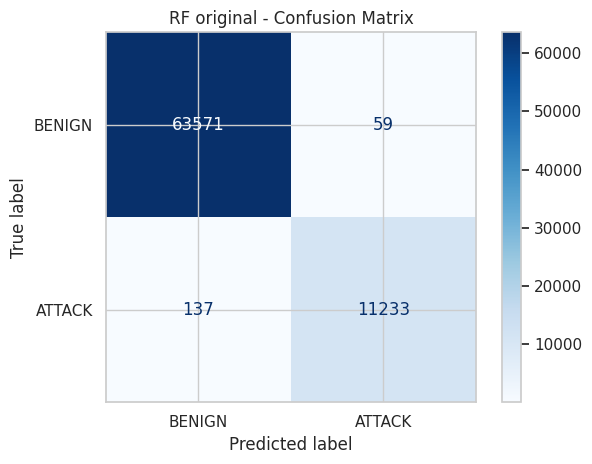

Training imbalance experiment: RF class_weight

RF class_weight
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     63630
      ATTACK       0.99      0.99      0.99     11370

    accuracy                           1.00     75000
   macro avg       1.00      1.00      1.00     75000
weighted avg       1.00      1.00      1.00     75000



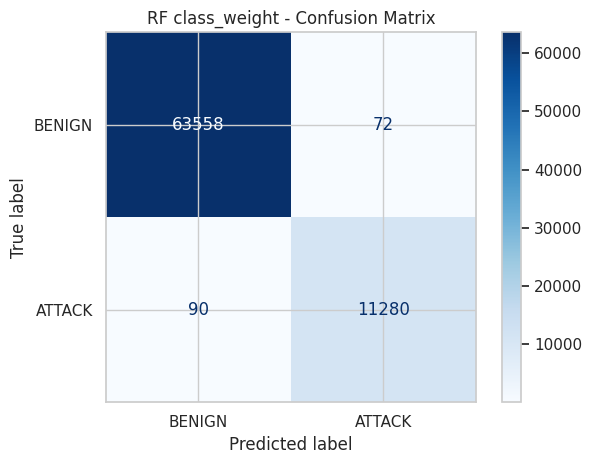

Training imbalance experiment: RF undersampled

RF undersampled
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     63630
      ATTACK       0.99      0.99      0.99     11370

    accuracy                           1.00     75000
   macro avg       0.99      1.00      0.99     75000
weighted avg       1.00      1.00      1.00     75000



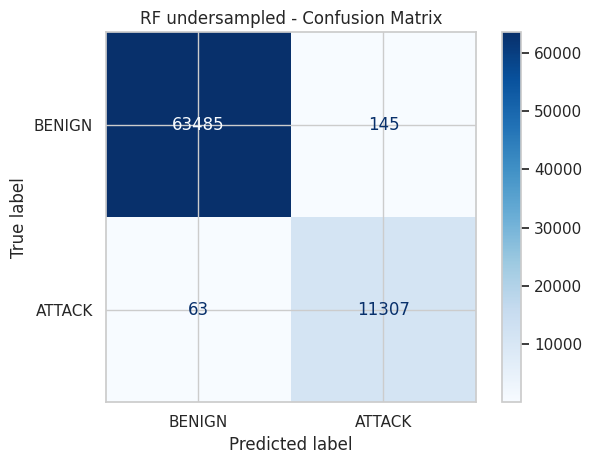

Training imbalance experiment: RF oversampled

RF oversampled
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     63630
      ATTACK       0.99      0.99      0.99     11370

    accuracy                           1.00     75000
   macro avg       1.00      1.00      1.00     75000
weighted avg       1.00      1.00      1.00     75000



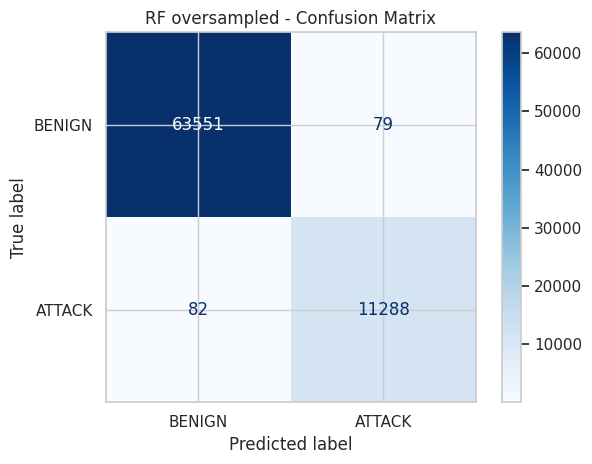

,model,accuracy,precision_attack,recall_attack,f1_attack,resampling_strategy,training_rows
3,RF oversampled,0.997853,0.993050,0.992788,0.992919,oversample,135786
1,RF class_weight,0.997840,0.993658,0.992084,0.992870,none,80000
0,RF original,0.997387,0.994775,0.987951,0.991351,none,80000
2,RF undersampled,0.997227,0.987338,0.994459,0.990886,undersample,24214


In [ ]:
def resample_binary_training_data(X_input, y_input, strategy):
    data = X_input.copy()
    data["_target"] = y_input.values

    class_counts = data["_target"].value_counts()
    if len(class_counts) < 2:
        return X_input, y_input

    majority_label = class_counts.idxmax()
    minority_label = class_counts.idxmin()
    majority = data[data["_target"] == majority_label]
    minority = data[data["_target"] == minority_label]

    if strategy == "undersample":
        majority_resampled = majority.sample(len(minority), random_state=RANDOM_STATE)
        balanced = pd.concat([majority_resampled, minority], ignore_index=True)
    elif strategy == "oversample":
        minority_resampled = minority.sample(len(majority), replace=True, random_state=RANDOM_STATE)
        balanced = pd.concat([majority, minority_resampled], ignore_index=True)
    else:
        balanced = data

    balanced = balanced.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
    return balanced.drop(columns="_target"), balanced["_target"]


IMBALANCE_EXPERIMENT_SAMPLE = min(80_000, len(X_train))
if len(X_train) > IMBALANCE_EXPERIMENT_SAMPLE:
    imbalance_sample_idx = X_train.sample(IMBALANCE_EXPERIMENT_SAMPLE, random_state=RANDOM_STATE).index
    X_train_imbalance = X_train.loc[imbalance_sample_idx]
    y_train_imbalance = y_train.loc[imbalance_sample_idx]
else:
    X_train_imbalance = X_train
    y_train_imbalance = y_train

imbalance_experiments = [
    (
        "RF original",
        RandomForestClassifier(n_estimators=120, min_samples_leaf=2, n_jobs=-1, random_state=RANDOM_STATE),
        "none",
    ),
    (
        "RF class_weight",
        RandomForestClassifier(
            n_estimators=120,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
        "none",
    ),
    (
        "RF undersampled",
        RandomForestClassifier(n_estimators=120, min_samples_leaf=2, n_jobs=-1, random_state=RANDOM_STATE),
        "undersample",
    ),
    (
        "RF oversampled",
        RandomForestClassifier(n_estimators=120, min_samples_leaf=2, n_jobs=-1, random_state=RANDOM_STATE),
        "oversample",
    ),
]

imbalance_results = []

for name, model, resampling_strategy in imbalance_experiments:
    print(f"Training imbalance experiment: {name}")
    X_resampled, y_resampled = resample_binary_training_data(
        X_train_imbalance,
        y_train_imbalance,
        resampling_strategy,
    )
    model.fit(X_resampled, y_resampled)
    predictions = model.predict(X_test)
    metrics = evaluate_predictions(name, y_test, predictions)
    metrics["resampling_strategy"] = resampling_strategy
    metrics["training_rows"] = len(X_resampled)
    imbalance_results.append(metrics)

imbalance_results_df = pd.DataFrame(imbalance_results).sort_values("f1_attack", ascending=False)
display(imbalance_results_df)


# Train and Evaluate Models


Rule-Based Baseline
              precision    recall  f1-score   support

      BENIGN       0.89      0.96      0.92     63630
      ATTACK       0.57      0.33      0.42     11370

    accuracy                           0.86     75000
   macro avg       0.73      0.64      0.67     75000
weighted avg       0.84      0.86      0.84     75000



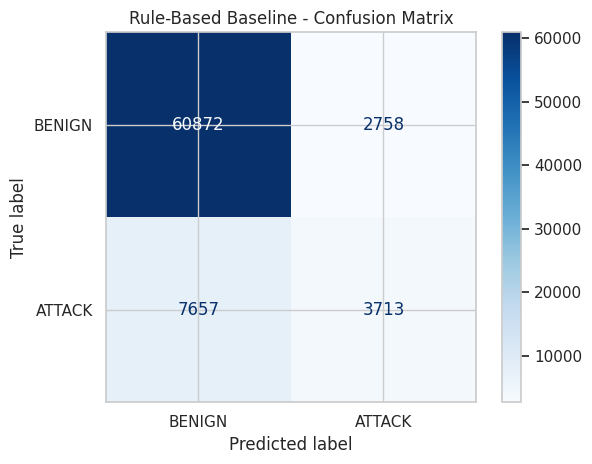

Training Dummy Majority...

Dummy Majority
              precision    recall  f1-score   support

      BENIGN       0.85      1.00      0.92     63630
      ATTACK       0.00      0.00      0.00     11370

    accuracy                           0.85     75000
   macro avg       0.42      0.50      0.46     75000
weighted avg       0.72      0.85      0.78     75000



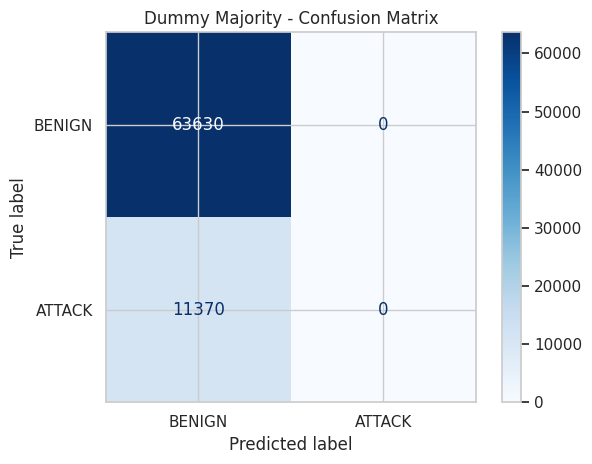

Training Logistic Regression...

Logistic Regression
              precision    recall  f1-score   support

      BENIGN       0.99      0.92      0.96     63630
      ATTACK       0.69      0.96      0.80     11370

    accuracy                           0.93     75000
   macro avg       0.84      0.94      0.88     75000
weighted avg       0.95      0.93      0.93     75000



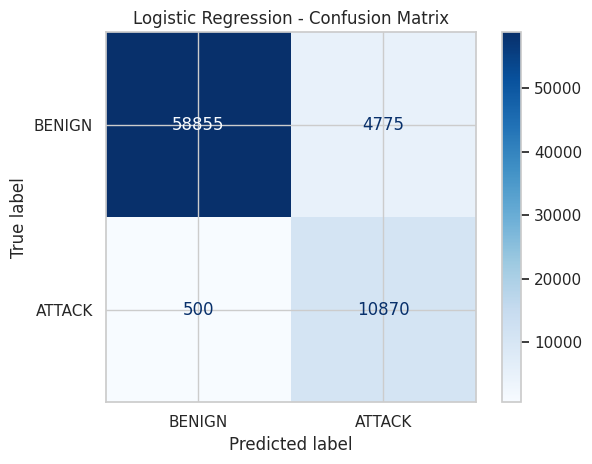

Training Random Forest...

Random Forest
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     63630
      ATTACK       0.99      0.99      0.99     11370

    accuracy                           1.00     75000
   macro avg       1.00      1.00      1.00     75000
weighted avg       1.00      1.00      1.00     75000



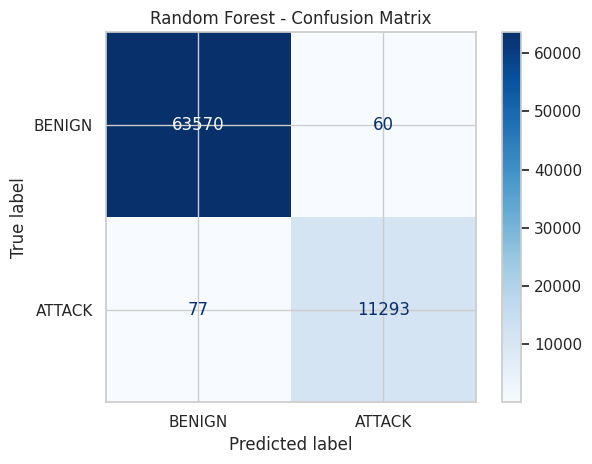

Training HistGradientBoosting...

HistGradientBoosting
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     63630
      ATTACK       0.99      1.00      1.00     11370

    accuracy                           1.00     75000
   macro avg       1.00      1.00      1.00     75000
weighted avg       1.00      1.00      1.00     75000



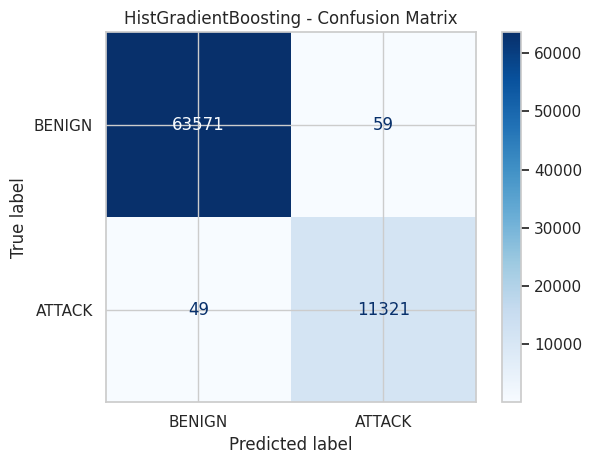

,model,accuracy,precision_attack,recall_attack,f1_attack
4,HistGradientBoosting,0.998560,0.994815,0.995690,0.995253
3,Random Forest,0.998173,0.994715,0.993228,0.993971
2,Logistic Regression,0.929667,0.694791,0.956025,0.804738
0,Rule-Based Baseline,0.861133,0.573791,0.326561,0.416232
1,Dummy Majority,0.848400,0.000000,0.000000,0.000000


In [ ]:
models = {
    "Dummy Majority": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
        ]
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=150,
        learning_rate=0.08,
        max_leaf_nodes=31,
        random_state=RANDOM_STATE,
    ),
}

trained_models = {}
results = []

rule_predictions = rule_based_predict(X_train, y_train, X_test)
results.append(evaluate_predictions("Rule-Based Baseline", y_test, rule_predictions))

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model
    predictions = model.predict(X_test)
    results.append(evaluate_predictions(name, y_test, predictions))

results_df = pd.DataFrame(results).sort_values("f1_attack", ascending=False)
display(results_df)


# Cross-Validation and Hyperparameter Tuning

Cross-validating Logistic Regression...
Cross-validating Random Forest...
Cross-validating HistGradientBoosting...


,model,mean_test_f1_attack,std_test_f1_attack,mean_test_recall_attack,std_test_recall_attack,mean_test_precision_attack,std_test_precision_attack,mean_test_balanced_accuracy,std_test_balanced_accuracy
2,HistGradientBoosting,0.991650,0.001323,0.990986,0.000409,0.992316,0.002240,0.994817,0.000403
1,Random Forest,0.988951,0.002176,0.986146,0.002722,0.991773,0.001671,0.992353,0.001501
0,Logistic Regression,0.807631,0.003397,0.952762,0.007565,0.700891,0.002551,0.940567,0.003586


Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best Random Forest parameters: {'max_depth': 24, 'min_samples_leaf': 1, 'n_estimators': 120}
Best cross-validation attack F1: 0.9895

Tuned Random Forest
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     63630
      ATTACK       1.00      0.99      0.99     11370

    accuracy                           1.00     75000
   macro avg       1.00      1.00      1.00     75000
weighted avg       1.00      1.00      1.00     75000



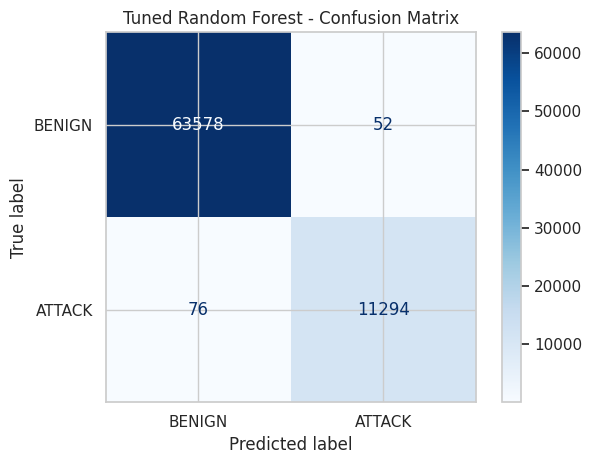

,model,accuracy,precision_attack,recall_attack,f1_attack
0,HistGradientBoosting,0.998560,0.994815,0.995690,0.995253
5,Tuned Random Forest,0.998293,0.995417,0.993316,0.994365
1,Random Forest,0.998173,0.994715,0.993228,0.993971
2,Logistic Regression,0.929667,0.694791,0.956025,0.804738
3,Rule-Based Baseline,0.861133,0.573791,0.326561,0.416232
4,Dummy Majority,0.848400,0.000000,0.000000,0.000000


In [ ]:
CV_SAMPLE_SIZE = min(40_000, len(X_train))
if len(X_train) > CV_SAMPLE_SIZE:
    cv_sample_idx = X_train.sample(CV_SAMPLE_SIZE, random_state=RANDOM_STATE).index
    X_train_cv = X_train.loc[cv_sample_idx]
    y_train_cv = y_train.loc[cv_sample_idx]
else:
    X_train_cv = X_train
    y_train_cv = y_train

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
attack_f1_scorer = make_scorer(f1_score, pos_label="ATTACK", zero_division=0)
attack_recall_scorer = make_scorer(recall_score, pos_label="ATTACK", zero_division=0)
attack_precision_scorer = make_scorer(precision_score, pos_label="ATTACK", zero_division=0)

cv_scoring = {
    "f1_attack": attack_f1_scorer,
    "recall_attack": attack_recall_scorer,
    "precision_attack": attack_precision_scorer,
    "balanced_accuracy": make_scorer(balanced_accuracy_score),
}

cv_models = {
    "Logistic Regression": clone(models["Logistic Regression"]),
    "Random Forest": RandomForestClassifier(
        n_estimators=120,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "HistGradientBoosting": clone(models["HistGradientBoosting"]),
}

cv_rows = []
for name, model in cv_models.items():
    print(f"Cross-validating {name}...")
    scores = cross_validate(
        model,
        X_train_cv,
        y_train_cv,
        cv=cv,
        scoring=cv_scoring,
        n_jobs=-1,
        return_train_score=False,
    )
    row = {"model": name}
    for metric_name in cv_scoring:
        values = scores[f"test_{metric_name}"]
        row[f"mean_test_{metric_name}"] = values.mean()
        row[f"std_test_{metric_name}"] = values.std()
    cv_rows.append(row)

cv_summary = pd.DataFrame(cv_rows).sort_values("mean_test_f1_attack", ascending=False)
display(cv_summary)

rf_param_grid = {
    "n_estimators": [120],
    "max_depth": [None, 24],
    "min_samples_leaf": [1, 3],
}

rf_search = GridSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    param_grid=rf_param_grid,
    scoring=attack_f1_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

rf_search.fit(X_train_cv, y_train_cv)
print("Best Random Forest parameters:", rf_search.best_params_)
print(f"Best cross-validation attack F1: {rf_search.best_score_:.4f}")

best_rf_model = clone(rf_search.best_estimator_)
best_rf_model.fit(X_train, y_train)
trained_models["Tuned Random Forest"] = best_rf_model

tuned_rf_predictions = best_rf_model.predict(X_test)
tuned_rf_metrics = evaluate_predictions("Tuned Random Forest", y_test, tuned_rf_predictions)
results_df = pd.concat([results_df, pd.DataFrame([tuned_rf_metrics])], ignore_index=True)
results_df = results_df.sort_values("f1_attack", ascending=False).drop_duplicates("model", keep="first")
display(results_df)


# Source-File Holdout Evaluation

Held-out source files:
[np.str_('Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'), np.str_('Tuesday-WorkingHours.pcap_ISCX.csv')]
Source train shape: (224964, 69)
Source test shape: (75036, 69)

Logistic Regression - Source File Holdout
              precision    recall  f1-score   support

      BENIGN       0.87      0.96      0.91     55140
      ATTACK       0.84      0.61      0.71     19896

    accuracy                           0.87     75036
   macro avg       0.86      0.79      0.81     75036
weighted avg       0.86      0.87      0.86     75036



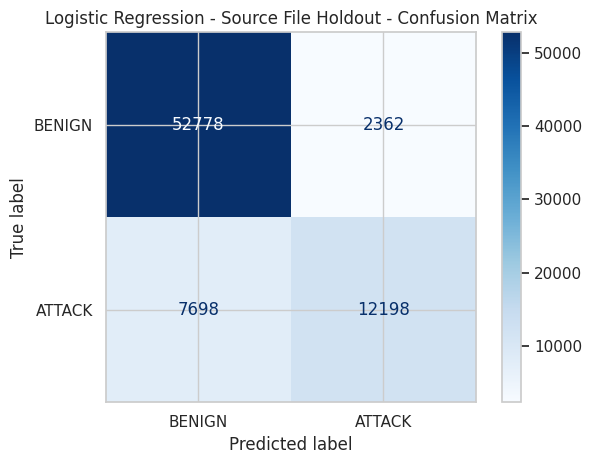


Random Forest - Source File Holdout
              precision    recall  f1-score   support

      BENIGN       0.88      1.00      0.93     55140
      ATTACK       0.99      0.61      0.75     19896

    accuracy                           0.90     75036
   macro avg       0.94      0.80      0.84     75036
weighted avg       0.91      0.90      0.89     75036



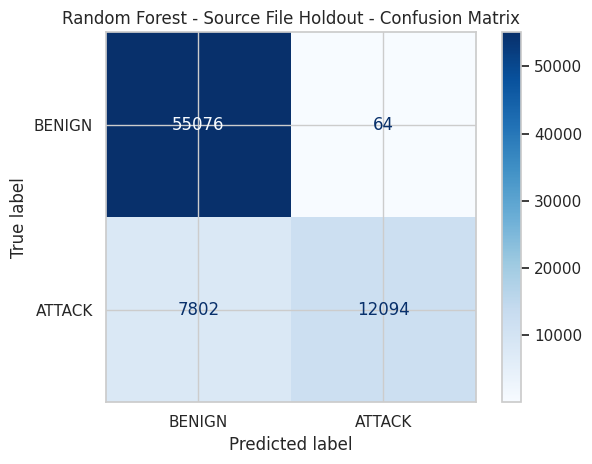


HistGradientBoosting - Source File Holdout
              precision    recall  f1-score   support

      BENIGN       0.88      1.00      0.93     55140
      ATTACK       1.00      0.61      0.76     19896

    accuracy                           0.90     75036
   macro avg       0.94      0.80      0.84     75036
weighted avg       0.91      0.90      0.89     75036



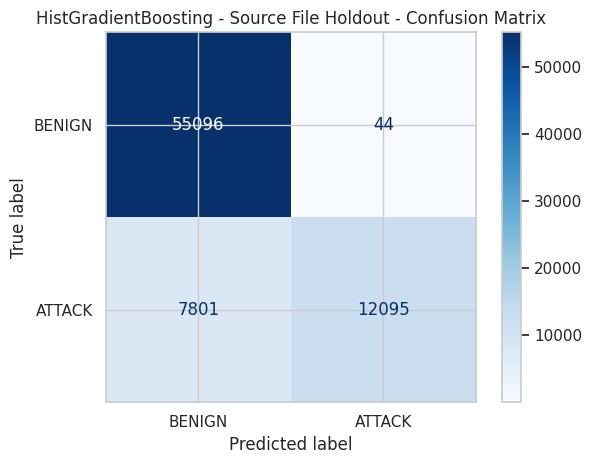

,model,accuracy,precision_attack,recall_attack,f1_attack
0,HistGradientBoosting - Source File Holdout,0.895450,0.996375,0.607911,0.755112
1,Random Forest - Source File Holdout,0.895170,0.994736,0.607861,0.754602
2,Logistic Regression - Source File Holdout,0.865931,0.837775,0.613088,0.708033


In [ ]:
from sklearn.base import clone

source_split_results_df = pd.DataFrame()

if "source_file" not in raw_data.columns or raw_data["source_file"].nunique() < 2:
    print("Source-file holdout skipped because source_file is unavailable or has fewer than two files.")
else:
    source_labels = raw_data.loc[X.index, "source_file"].astype(str)
    unique_files = np.array(sorted(source_labels.unique()))
    n_test_files = max(1, int(round(len(unique_files) * 0.25)))
    rng = np.random.default_rng(RANDOM_STATE)

    chosen_test_files = None
    for _ in range(250):
        candidate_files = set(rng.choice(unique_files, size=n_test_files, replace=False))
        test_mask = source_labels.isin(candidate_files)
        y_train_source_candidate = y_binary.loc[~test_mask]
        y_test_source_candidate = y_binary.loc[test_mask]

        if y_train_source_candidate.nunique() == 2 and y_test_source_candidate.nunique() == 2:
            chosen_test_files = candidate_files
            break

    if chosen_test_files is None:
        print("Could not create a source-file split containing both binary classes in train and test.")
    else:
        source_test_mask = source_labels.isin(chosen_test_files)
        X_train_source = X.loc[~source_test_mask]
        X_test_source = X.loc[source_test_mask]
        y_train_source = y_binary.loc[~source_test_mask]
        y_test_source = y_binary.loc[source_test_mask]

        print("Held-out source files:")
        print(sorted(chosen_test_files))
        print(f"Source train shape: {X_train_source.shape}")
        print(f"Source test shape: {X_test_source.shape}")

source_holdout_models = {
    "Logistic Regression - Source File Holdout": clone(models["Logistic Regression"]),
    "Random Forest - Source File Holdout": clone(models["Random Forest"]),
    "HistGradientBoosting - Source File Holdout": clone(models["HistGradientBoosting"]),
}

source_holdout_results = []

for model_name, model in source_holdout_models.items():
    model.fit(X_train_source, y_train_source)
    source_predictions = model.predict(X_test_source)

    source_holdout_results.append(
        evaluate_predictions(
            model_name,
            y_test_source,
            source_predictions
        )
    )

source_split_results_df = (
    pd.DataFrame(source_holdout_results)
    .sort_values("f1_attack", ascending=False)
    .reset_index(drop=True)
)

display(source_split_results_df)


# Attack F1 Scores Comparison

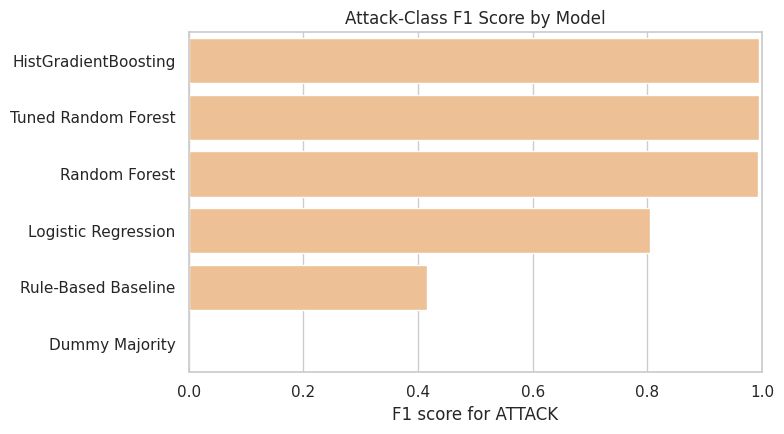

In [ ]:
plt.figure(figsize=(8, 4.5))
sns.barplot(data=results_df, x="f1_attack", y="model", color="#fdc086")
plt.xlim(0, 1)
plt.title("Attack-Class F1 Score by Model")
plt.xlabel("F1 score for ATTACK")
plt.ylabel("")
plt.tight_layout()
plt.show()


# Precision-Recall Curve and Threshold Tuning



HistGradientBoosting @ tuned threshold
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     63630
      ATTACK       1.00      0.99      0.99     11370

    accuracy                           1.00     75000
   macro avg       1.00      1.00      1.00     75000
weighted avg       1.00      1.00      1.00     75000



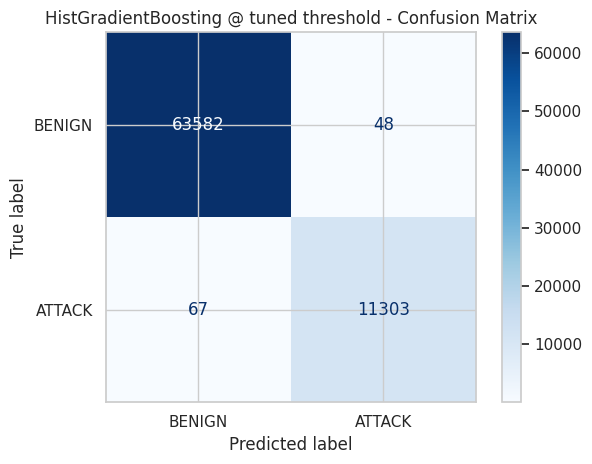

{'model': 'HistGradientBoosting', 'best_threshold': 0.5821409991553855, 'validation_precision': 0.9961854460093896, 'validation_recall': 0.9953092934623278, 'validation_f1': 0.9957471770054259, 'average_precision': 0.9996241442461277}


,threshold,precision,recall,f1
10795,0.582141,0.996185,0.995309,0.995747
10797,0.586213,0.996331,0.995016,0.995673
10794,0.581485,0.995893,0.995309,0.995601
10796,0.586144,0.996184,0.995016,0.995600
10798,0.610007,0.996330,0.994870,0.995599
10793,0.579982,0.995747,0.995309,0.995528
10799,0.613769,0.996329,0.994723,0.995526
10803,0.633484,0.996913,0.994137,0.995523
10804,0.634839,0.997059,0.993990,0.995522
10806,0.643643,0.997205,0.993843,0.995522


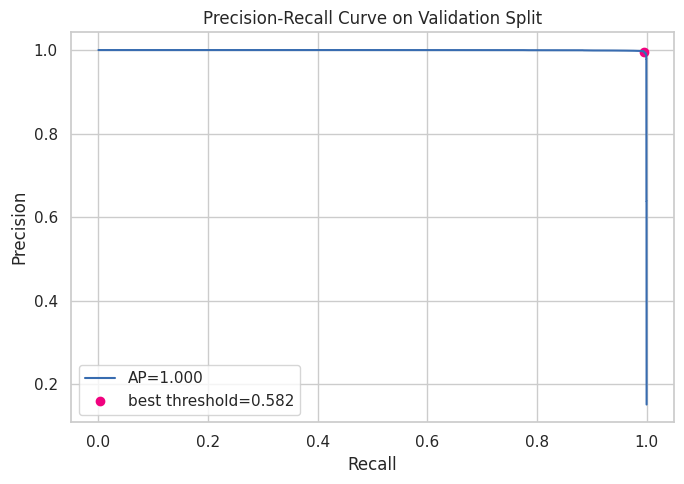

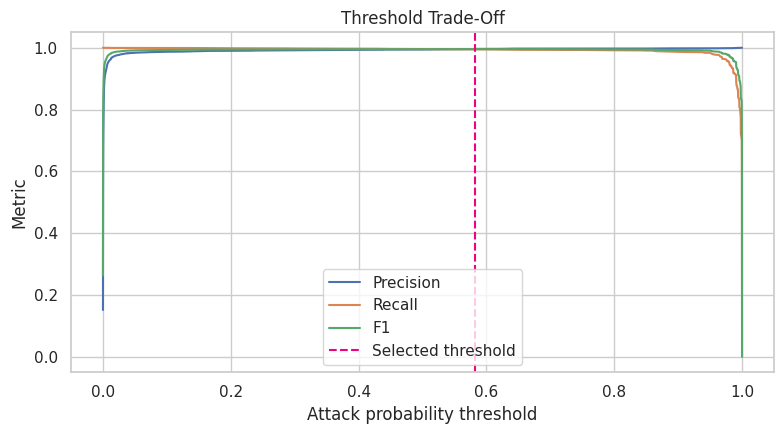

In [ ]:
def attack_probability(model, X_eval):
    if not hasattr(model, "predict_proba"):
        raise TypeError("Model does not provide predict_proba.")

    classes = list(model.classes_)
    if "ATTACK" not in classes:
        raise ValueError("Model classes do not include ATTACK.")

    attack_index = classes.index("ATTACK")
    return model.predict_proba(X_eval)[:, attack_index]


probability_model_names = [
    name
    for name in results_df["model"]
    if name in trained_models and hasattr(trained_models[name], "predict_proba")
]

if not probability_model_names:
    print("No probability-based model available for threshold tuning.")
else:
    threshold_model_name = probability_model_names[0]
    threshold_model_template = clone(trained_models[threshold_model_name])

    X_train_threshold, X_val_threshold, y_train_threshold, y_val_threshold = train_test_split(
        X_train,
        y_train,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y_train,
    )

    threshold_model_template.fit(X_train_threshold, y_train_threshold)
    val_scores = attack_probability(threshold_model_template, X_val_threshold)
    val_true_binary = y_val_threshold.eq("ATTACK").astype(int)

    precision, recall, thresholds = precision_recall_curve(val_true_binary, val_scores)
    average_precision = average_precision_score(val_true_binary, val_scores)

    threshold_table = pd.DataFrame(
        {
            "threshold": thresholds,
            "precision": precision[:-1],
            "recall": recall[:-1],
        }
    )
    threshold_table["f1"] = (
        2
        * threshold_table["precision"]
        * threshold_table["recall"]
        / (threshold_table["precision"] + threshold_table["recall"]).replace(0, np.nan)
    ).fillna(0)

    best_threshold_row = threshold_table.sort_values("f1", ascending=False).iloc[0]
    best_threshold = float(best_threshold_row["threshold"])

    test_scores = attack_probability(threshold_model_template, X_test)
    tuned_threshold_predictions = np.where(test_scores >= best_threshold, "ATTACK", "BENIGN")

    threshold_metrics = evaluate_predictions(
        f"{threshold_model_name} @ tuned threshold",
        y_test,
        tuned_threshold_predictions,
    )
    results_df = pd.concat([results_df, pd.DataFrame([threshold_metrics])], ignore_index=True)
    results_df = results_df.sort_values("f1_attack", ascending=False).drop_duplicates("model", keep="first")

    threshold_analysis = {
        "model": threshold_model_name,
        "best_threshold": best_threshold,
        "validation_precision": float(best_threshold_row["precision"]),
        "validation_recall": float(best_threshold_row["recall"]),
        "validation_f1": float(best_threshold_row["f1"]),
        "average_precision": float(average_precision),
    }

    print(threshold_analysis)
    display(threshold_table.sort_values("f1", ascending=False).head(10))

    plt.figure(figsize=(7, 5))
    plt.plot(recall, precision, color="#386cb0", label=f"AP={average_precision:.3f}")
    plt.scatter(
        best_threshold_row["recall"],
        best_threshold_row["precision"],
        color="#f0027f",
        label=f"best threshold={best_threshold:.3f}",
    )
    plt.title("Precision-Recall Curve on Validation Split")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4.5))
    sns.lineplot(data=threshold_table, x="threshold", y="precision", label="Precision")
    sns.lineplot(data=threshold_table, x="threshold", y="recall", label="Recall")
    sns.lineplot(data=threshold_table, x="threshold", y="f1", label="F1")
    plt.axvline(best_threshold, color="#f0027f", linestyle="--", label="Selected threshold")
    plt.title("Threshold Trade-Off")
    plt.xlabel("Attack probability threshold")
    plt.ylabel("Metric")
    plt.legend()
    plt.tight_layout()
    plt.show()


# False Positive and False Negative Analysis


In [ ]:
analysis_model_name = results_df.iloc[0]["model"]

if analysis_model_name in trained_models:
    analysis_predictions = trained_models[analysis_model_name].predict(X_test)
elif "tuned_threshold_predictions" in globals():
    analysis_model_name = f"{threshold_model_name} @ tuned threshold"
    analysis_predictions = tuned_threshold_predictions
else:
    analysis_model_name = "Random Forest"
    analysis_predictions = trained_models["Random Forest"].predict(X_test)

error_analysis = pd.DataFrame(
    {
        "true_label": y_test.values,
        "predicted_label": analysis_predictions,
    },
    index=y_test.index,
)

if "source_file" in raw_data.columns:
    error_analysis["source_file"] = raw_data.loc[error_analysis.index, "source_file"].values

false_positives = error_analysis[
    (error_analysis["true_label"] == "BENIGN")
    & (error_analysis["predicted_label"] == "ATTACK")
]
false_negatives = error_analysis[
    (error_analysis["true_label"] == "ATTACK")
    & (error_analysis["predicted_label"] == "BENIGN")
]

print(f"Error analysis model: {analysis_model_name}")
print(f"False positives: {len(false_positives)}")
print(f"False negatives: {len(false_negatives)}")

if len(false_negatives) > len(false_positives):
    print("Main risk: missed attacks. Consider lowering the attack threshold or prioritizing recall.")
elif len(false_positives) > len(false_negatives):
    print("Main risk: alert fatigue. Consider raising the attack threshold or improving feature filtering.")
else:
    print("False positives and false negatives are balanced in this split.")

if "source_file" in error_analysis.columns:
    error_by_file = error_analysis.assign(
        error_type=np.select(
            [
                (error_analysis["true_label"] == "BENIGN") & (error_analysis["predicted_label"] == "ATTACK"),
                (error_analysis["true_label"] == "ATTACK") & (error_analysis["predicted_label"] == "BENIGN"),
            ],
            ["false_positive", "false_negative"],
            default="correct",
        )
    )
    display(pd.crosstab(error_by_file["source_file"], error_by_file["error_type"]))

display(false_positives.head())
display(false_negatives.head())


Error analysis model: HistGradientBoosting
False positives: 59
False negatives: 49
Main risk: alert fatigue. Consider raising the attack threshold or improving feature filtering.


error_type,correct,false_negative,false_positive
source_file,,,
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,9361,2,2
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv,9260,1,4
Friday-WorkingHours-Morning.pcap_ISCX.csv,9354,20,3
Monday-WorkingHours.pcap_ISCX.csv,9430,0,4
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv,9420,0,37
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv,9368,7,4
Tuesday-WorkingHours.pcap_ISCX.csv,9316,1,1
Wednesday-workingHours.pcap_ISCX.csv,9383,18,4


,true_label,predicted_label,source_file
1012,BENIGN,ATTACK,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...
136238,BENIGN,ATTACK,Thursday-WorkingHours-Afternoon-Infilteration....
84860,BENIGN,ATTACK,Thursday-WorkingHours-Afternoon-Infilteration....
206126,BENIGN,ATTACK,Thursday-WorkingHours-Afternoon-Infilteration....
59123,BENIGN,ATTACK,Thursday-WorkingHours-Afternoon-Infilteration....


,true_label,predicted_label,source_file
143025,ATTACK,BENIGN,Thursday-WorkingHours-Morning-WebAttacks.pcap_...
67767,ATTACK,BENIGN,Thursday-WorkingHours-Morning-WebAttacks.pcap_...
32660,ATTACK,BENIGN,Wednesday-workingHours.pcap_ISCX.csv
158187,ATTACK,BENIGN,Friday-WorkingHours-Morning.pcap_ISCX.csv
286942,ATTACK,BENIGN,Friday-WorkingHours-Morning.pcap_ISCX.csv


# Random Forest Feature Importance

,feature,importance
5,Fwd_Packet_Length_Max,0.063795
57,Init_Win_bytes_forward,0.061016
58,Init_Win_bytes_backward,0.050200
50,Avg_Fwd_Segment_Size,0.046018
7,Fwd_Packet_Length_Mean,0.045304
54,Subflow_Fwd_Bytes,0.044785
49,Average_Packet_Size,0.042888
3,Total_Length_of_Fwd_Packets,0.039981
39,Packet_Length_Variance,0.038178
10,Bwd_Packet_Length_Min,0.037068


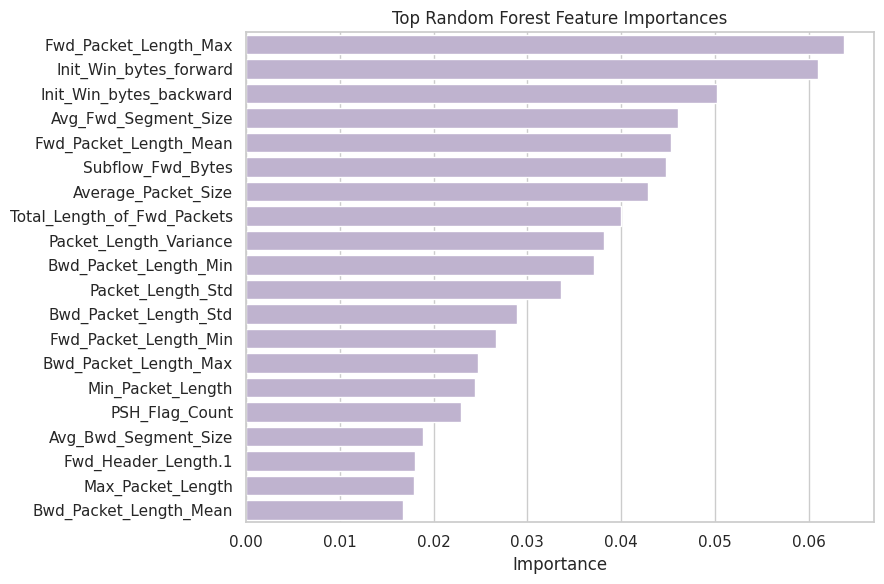

In [ ]:
rf_model = trained_models.get("Random Forest")

if rf_model is not None:
    importances = pd.DataFrame(
        {
            "feature": X_train.columns,
            "importance": rf_model.feature_importances_,
        }
    ).sort_values("importance", ascending=False)

    display(importances.head(20))

    plt.figure(figsize=(9, 6))
    sns.barplot(data=importances.head(20), x="importance", y="feature", color="#beaed4")
    plt.title("Top Random Forest Feature Importances")
    plt.xlabel("Importance")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()
else:
    print("Random Forest model was not trained.")


# Permutation Importance


,feature,importance_mean,importance_std
57,Init_Win_bytes_forward,0.027100,0.002673
23,Fwd_IAT_Min,0.007063,0.000471
58,Init_Win_bytes_backward,0.005438,0.000519
52,Fwd_Header_Length.1,0.001418,0.000483
31,Fwd_Header_Length,0.001031,0.000316
60,min_seg_size_forward,0.000902,0.000515
12,Bwd_Packet_Length_Std,0.000644,0.000000
45,URG_Flag_Count,0.000515,0.000258
49,Average_Packet_Size,0.000515,0.000258
2,Total_Backward_Packets,0.000000,0.000000


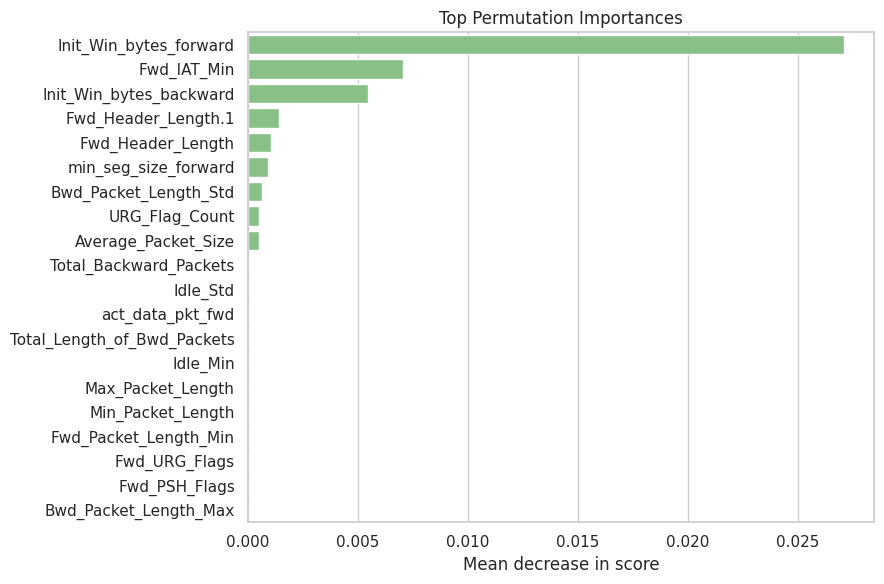

In [ ]:
importance_model = trained_models.get("Tuned Random Forest", trained_models.get("Random Forest"))

PERMUTATION_SAMPLE_SIZE = min(5_000, len(X_test))
permutation_idx = X_test.sample(PERMUTATION_SAMPLE_SIZE, random_state=RANDOM_STATE).index

permutation_scores = permutation_importance(
    importance_model,
    X_test.loc[permutation_idx],
    y_test.loc[permutation_idx],
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scoring=attack_f1_scorer if "attack_f1_scorer" in globals() else "f1_macro",
)

permutation_importances = pd.DataFrame(
    {
        "feature": X_test.columns,
        "importance_mean": permutation_scores.importances_mean,
        "importance_std": permutation_scores.importances_std,
    }
).sort_values("importance_mean", ascending=False)

display(permutation_importances.head(20))

plt.figure(figsize=(9, 6))
sns.barplot(
    data=permutation_importances.head(20),
    x="importance_mean",
    y="feature",
    color="#7fc97f",
)
plt.title("Top Permutation Importances")
plt.xlabel("Mean decrease in score")
plt.ylabel("")
plt.tight_layout()
plt.show()


# SHAP Explainability


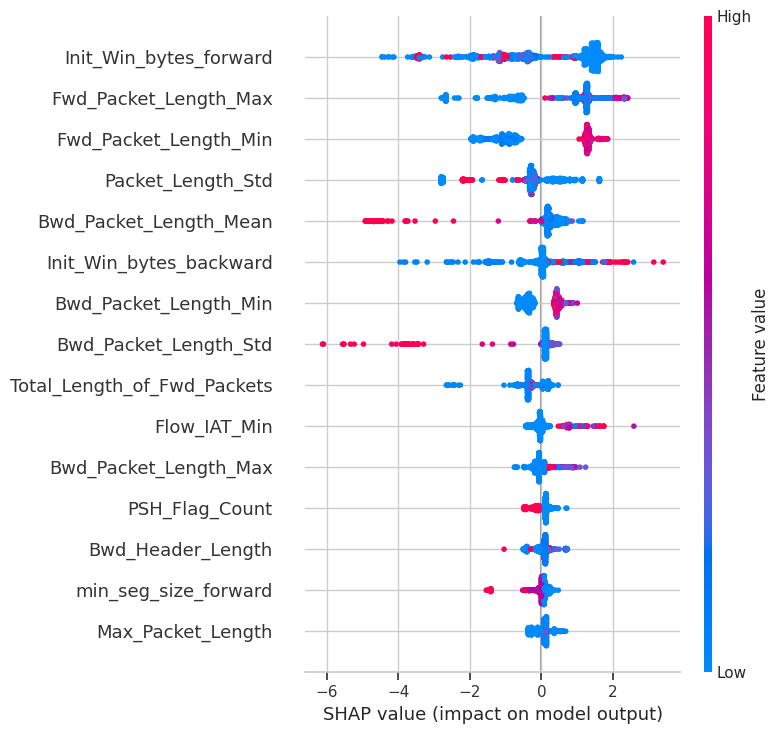

In [ ]:
RUN_SHAP = True

if RUN_SHAP:
    try:
        import shap

        shap_model = trained_models.get("HistGradientBoosting")

        if shap_model is None:
            raise ValueError("HistGradientBoosting model was not found in trained_models.")

        shap_sample_size = min(1000, len(X_test))
        shap_sample = X_test.sample(shap_sample_size, random_state=RANDOM_STATE)

        explainer = shap.TreeExplainer(shap_model)
        shap_values = explainer.shap_values(shap_sample)

        shap.summary_plot(
            shap_values,
            shap_sample,
            max_display=15,
            show=True
        )

    except ImportError:
        print("SHAP is not installed. Run: pip install shap")
    except Exception as error:
        print(f"SHAP explanation skipped: {error}")
else:
    print("SHAP skipped. Set RUN_SHAP = True to run optional SHAP explanations.")

# Multiclass Classification

In [ ]:
RUN_MULTICLASS = True

if RUN_MULTICLASS and y_raw.nunique() > 2:
    le = LabelEncoder()
    y_multi = pd.Series(le.fit_transform(y_raw), index=y_raw.index, name="multiclass_label")
    class_ids = np.arange(len(le.classes_))

    X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
        X,
        y_multi,
        test_size=0.25,
        random_state=RANDOM_STATE,
        stratify=y_multi,
    )

    multiclass_model_name = "HistGradientBoosting"

    multiclass_model = HistGradientBoostingClassifier(
        random_state=RANDOM_STATE,
        early_stopping=False
    )

    multiclass_model.fit(X_train_m, y_train_m)
    y_pred_m = multiclass_model.predict(X_test_m)

    present_ids = np.union1d(np.unique(y_test_m), np.unique(y_pred_m))
    missing_class_names = [
        le.classes_[class_id]
        for class_id in class_ids
        if class_id not in present_ids
    ]

    if missing_class_names:
        print("Classes absent from this test/prediction subset:")
        print(missing_class_names)

    print(classification_report(
        y_test_m,
        y_pred_m,
        labels=class_ids,
        target_names=le.classes_,
        zero_division=0,
    ))
else:
    print("Multiclass classification skipped because the dataset has only two labels or RUN_MULTICLASS is False.")


                            precision    recall  f1-score   support

                    BENIGN       0.93      0.87      0.90     63630
                       Bot       0.00      0.00      0.00        94
                      DDoS       0.93      0.99      0.96      4768
             DoS GoldenEye       0.01      0.00      0.00       356
                  DoS Hulk       0.03      0.03      0.03       577
          DoS Slowhttptest       0.00      0.00      0.00         7
             DoS slowloris       0.00      0.00      0.00        11
             FTP - Patator       0.00      0.00      0.00        62
                Heartbleed       0.00      0.00      0.00         1
              Infiltration       0.00      0.00      0.00         1
                  PortScan       0.25      0.46      0.32      5223
             SSH - Patator       0.00      0.00      0.00       144
  Web Attack - Brute Force       0.00      0.00      0.00        88
Web Attack - SQL Injection       0.00      0.00

# Binary vs Multiclass Comparison

In [ ]:
binary_best = results_df.sort_values("f1_attack", ascending=False).iloc[0]

comparison_rows = [
    {
        "task": "Binary detection",
        "objective": "BENIGN vs ATTACK",
        "model": binary_best["model"],
        "main_metric": "attack F1",
        "score": binary_best["f1_attack"],
    }
]

if "y_pred_m" in globals():
    multiclass_macro_f1 = f1_score(y_test_m, y_pred_m, average="macro", zero_division=0)
    multiclass_weighted_f1 = f1_score(y_test_m, y_pred_m, average="weighted", zero_division=0)

    comparison_rows.append(
        {
            "task": "Multiclass classification",
            "objective": "Specific attack category",
            "model": multiclass_model_name,
            "main_metric": "macro F1",
            "score": multiclass_macro_f1,
        }
    )
    comparison_rows.append(
        {
            "task": "Multiclass classification",
            "objective": "Specific attack category",
            "model": multiclass_model_name,
            "main_metric": "weighted F1",
            "score": multiclass_weighted_f1,
        }
    )

task_comparison = pd.DataFrame(comparison_rows)
display(task_comparison)

print(
    "Binary detection is usually the first IDS decision. "
    "Multiclass prediction is harder because rare attack categories may have very few examples."
)

,task,objective,model,main_metric,score
0,Binary detection,BENIGN vs ATTACK,HistGradientBoosting,attack F1,0.995253
1,Multiclass classification,Specific attack category,HistGradientBoosting,macro F1,0.147532
2,Multiclass classification,Specific attack category,HistGradientBoosting,weighted F1,0.845060


Binary detection is usually the first IDS decision. Multiclass prediction is harder because rare attack categories may have very few examples.


# Save Best Model Prototype

In [ ]:
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

candidate_model_rows = results_df[results_df["model"].isin(trained_models.keys())]
if candidate_model_rows.empty:
    selected_model_name = "Random Forest"
else:
    selected_model_name = candidate_model_rows.sort_values("f1_attack", ascending=False).iloc[0]["model"]

selected_model = trained_models[selected_model_name]
feature_columns = list(X.columns)
feature_medians = X_train.median(numeric_only=True)

model_package = {
    "model": selected_model,
    "model_name": selected_model_name,
    "feature_columns": feature_columns,
    "feature_medians": feature_medians,
    "target_type": "binary_intrusion_detection",
    "positive_class": "ATTACK",
}

model_path = models_dir / "best_binary_intrusion_model.joblib"
joblib.dump(model_package, model_path)


def predict_network_flow(flow_dict, model_package=model_package):
    flow_df = pd.DataFrame([flow_dict])
    flow_df = clean_column_names(flow_df)
    flow_df = flow_df.reindex(columns=model_package["feature_columns"])
    flow_df = flow_df.replace([np.inf, -np.inf], np.nan)
    flow_df = flow_df.fillna(model_package["feature_medians"])

    model = model_package["model"]
    prediction = model.predict(flow_df)[0]

    result = {
        "prediction": prediction,
        "model": model_package["model_name"],
    }

    if hasattr(model, "predict_proba") and "ATTACK" in list(model.classes_):
        attack_index = list(model.classes_).index("ATTACK")
        result["attack_probability"] = float(model.predict_proba(flow_df)[:, attack_index][0])

    return result


example_flow = X_test.iloc[0].to_dict()
print(f"Saved model package to: {model_path.resolve()}")
print(predict_network_flow(example_flow))


Saved model package to: /content/models/best_binary_intrusion_model.joblib
{'prediction': 'BENIGN', 'model': 'HistGradientBoosting', 'attack_probability': 0.0001824367712324193}


# Final Project Conclusion

In [ ]:
best_binary = results_df.sort_values("f1_attack", ascending=False).iloc[0]

conclusion_lines = [
    "Final conclusion",
    "================",
    f"The project used {len(raw_data):,} CICIDS2017 flow records with {X.shape[1]} numerical features.",
    f"The best binary intrusion-detection model was {best_binary['model']} with attack F1={best_binary['f1_attack']:.4f}.",
    f"Its attack recall was {best_binary['recall_attack']:.4f}, which is important because missed attacks are the most dangerous IDS error.",
]

if "threshold_analysis" in globals():
    conclusion_lines.append(
        f"Threshold tuning selected an attack-probability threshold of {threshold_analysis['best_threshold']:.4f} "
        f"on a validation split."
    )

if "imbalance_ratio" in globals() and not np.isnan(imbalance_ratio):
    conclusion_lines.append(
        f"The binary class imbalance ratio was approximately {imbalance_ratio:.2f}:1, "
        "so recall, precision and F1-score are more informative than accuracy alone."
    )

if "source_split_results_df" in globals() and not source_split_results_df.empty:
    source_score = source_split_results_df.iloc[0]["f1_attack"]
    conclusion_lines.append(
        f"A source-file holdout evaluation was also performed; its attack F1 was {source_score:.4f}. "
        "This is more realistic than a random split because it tests generalization across collection files."
    )

if "task_comparison" in globals():
    conclusion_lines.append(
        "Binary detection is the more reliable first-stage IDS task, while multiclass attack classification "
        "is useful for analysis but is more affected by rare attack classes."
    )

conclusion_lines.append(
    "Overall, the project shows that supervised machine learning can detect network intrusions effectively, "
    "but careful handling of class imbalance, threshold choice and evaluation strategy is necessary for a realistic IDS."
)

final_conclusion = "\n".join(conclusion_lines)
print(final_conclusion)


Final conclusion
The project used 300,000 CICIDS2017 flow records with 69 numerical features.
The best binary intrusion-detection model was HistGradientBoosting with attack F1=0.9953.
Its attack recall was 0.9957, which is important because missed attacks are the most dangerous IDS error.
Threshold tuning selected an attack-probability threshold of 0.5821 on a validation split.
The binary class imbalance ratio was approximately 5.60:1, so recall, precision and F1-score are more informative than accuracy alone.
A source-file holdout evaluation was also performed; its attack F1 was 0.7551. This is more realistic than a random split because it tests generalization across collection files.
Binary detection is the more reliable first-stage IDS task, while multiclass attack classification is useful for analysis but is more affected by rare attack classes.
Overall, the project shows that supervised machine learning can detect network intrusions effectively, but careful handling of class imbal

# Result Summary

In [ ]:
best_row = results_df.sort_values("f1_attack", ascending=False).iloc[0]

summary = {
    "dataset_source": dataset_source,
    "best_model_by_attack_f1": best_row["model"],
    "best_attack_f1": float(best_row["f1_attack"]),
    "best_attack_recall": float(best_row["recall_attack"]),
    "number_of_rows": int(len(raw_data)),
    "number_of_features": int(X.shape[1]),
    "binary_class_balance": y_binary.value_counts().to_dict(),
    "number_of_attack_types": int(y_raw.nunique()),
}

if "cv_summary" in globals():
    summary["best_cross_validation_model"] = cv_summary.sort_values("mean_test_f1_attack", ascending=False).iloc[0]["model"]

if "threshold_analysis" in globals():
    summary["best_validation_threshold"] = float(threshold_analysis["best_threshold"])
    summary["average_precision"] = float(threshold_analysis["average_precision"])

if "source_split_results_df" in globals():
    summary["source_file_holdout_completed"] = True

summary


{'dataset_source': 'data/cicids2017/huggingface_csvs',
 'best_model_by_attack_f1': 'HistGradientBoosting',
 'best_attack_f1': 0.9952527472527473,
 'best_attack_recall': 0.9956904133685136,
 'number_of_rows': 300000,
 'number_of_features': 69,
 'binary_class_balance': {'BENIGN': 254521, 'ATTACK': 45479},
 'number_of_attack_types': 15,
 'best_cross_validation_model': 'HistGradientBoosting',
 'best_validation_threshold': 0.5821409991553855,
 'average_precision': 0.9996241442461277,
 'source_file_holdout_completed': True}

# Save Results Table

In [ ]:
results_dir = Path("results")
models_dir = Path("models")
results_dir.mkdir(exist_ok=True)
models_dir.mkdir(exist_ok=True)

results_df.to_csv(results_dir / "model_comparison_results.csv", index=False)

if "imbalance_results_df" in globals():
    imbalance_results_df.to_csv(results_dir / "imbalance_strategy_results.csv", index=False)

if "cv_summary" in globals():
    cv_summary.to_csv(results_dir / "cross_validation_results.csv", index=False)

if "source_split_results_df" in globals():
    source_split_results_df.to_csv(results_dir / "source_file_holdout_results.csv", index=False)

if "attack_type_summary" in globals():
    attack_type_summary.to_csv(results_dir / "attack_type_summary.csv")

if "final_conclusion" in globals():
    (results_dir / "final_conclusion.txt").write_text(final_conclusion, encoding="utf-8")

print(f"Saved result artifacts under: {results_dir.resolve()}")


Saved result artifacts under: /content/results
